Today's topics:
* correlation and the Pearson `r`
* fitting a line with `scipy.stats.linregress`
* interpreting slope, intercept and predictions

# The gap between yielding and ultimate tensile strength

A titanium hip stem that yields has already failed.
A permanent bend in an implant means revision surgery, not a part that keeps doing its job a little worse.

So an implant designer watches the gap between the stress where an alloy starts to deform permanently and the highest engineering stress it reaches in a tensile test.

Those points are yield strength (YS) and ultimate tensile strength (UTS). Call UTS minus YS the margin.
Fracture comes after the UTS peak on the engineering stress–strain curve.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/6f/Al_tensile_test.jpg" alt="An aluminum alloy tensile specimen broken in two, with visible necking near the break and a cup and cone fracture surface" width=520/>

A tensile specimen taken to fracture.
Photo by Sigmund, [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Al_tensile_test.jpg).

The narrowing near the break is the permanent deformation, and it started long before the specimen came apart.

The two schematic alloys have very different yield strengths but the same 204 MPa margin from YS to the UTS peak.
Today we ask whether that holds across a whole compilation of alloys, and the tool for asking is a fitted line.

# Rows with both measurements: `.dropna`

We met this compilation of titanium implant alloys in L05, when we looked at the spread of yield strengths across 283 alloys.
([Salvador et al., *Scientific Data* 9, 188](https://doi.org/10.1038/s41597-022-01283-9), CC BY 4.0.)

We return to it with a new question: given an alloy's yield strength, what is its ultimate tensile strength likely to be?

In [1]:
#@title Load the Ti-alloy dataset (click ▶ to run, data loading, not a learning objective) { display-mode: "form" }
import os

import pandas as pd


def _find(name):
    return next(
        (p for p in (f'datasets/{name}', f'../datasets/{name}', f'../../datasets/{name}',
                     f'../../../datasets/{name}')
         if os.path.exists(p)),
        f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{name}',
    )


try:
    data = pd.read_csv(_find('biomaterials_ti_alloys.csv'))
except Exception as e:
    raise RuntimeError(
        "Could not load the Ti-alloy data. If you are in Colab, check your "
        "internet connection."
    ) from e

print(f'Loaded {len(data)} titanium alloys')
data[['eid', 'YS_MPa', 'UTS_MPa']].head()

Loaded 283 titanium alloys


,eid,YS_MPa,UTS_MPa
0,Ti-23Nb-10Zr-2.0Fe,782.0,NaN
1,Ti-27Nb-10Zr-1.5Fe,735.0,NaN
2,Ti-31Nb-10Zr-1.0Fe,672.0,NaN
3,Ti-11Nb-7Zr-3.5Fe,1011.0,NaN
4,Ti-19Nb-6Sn-2.5Fe,765.0,NaN


In [2]:
display(data.head())
print(data.shape)

,eid,Al_frac,Cr_frac,Cu_frac,Fe_frac,Hf_frac,Mn_frac,Mo_frac,Nb_frac,Ni_frac,...,DAR_pct,DAR_err,test_mode,HV,HV_err,Mo_equivalent,Mo_equivalent_class,ref_doi,ref_key,comments
0,Ti-23Nb-10Zr-2.0Fe,0.0,0.0,0.0,0.023400,0.0,0.0,0.0,0.135800,0.0,...,10.0,1.0,tension,252.0,8.0,12.88,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
1,Ti-27Nb-10Zr-1.5Fe,0.0,0.0,0.0,0.015600,0.0,0.0,0.0,0.163200,0.0,...,9.0,1.0,tension,229.0,2.0,11.65,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
2,Ti-31Nb-10Zr-1.0Fe,0.0,0.0,0.0,0.013801,0.0,0.0,0.0,0.189919,0.0,...,15.0,6.0,tension,218.0,5.0,12.08,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
3,Ti-11Nb-7Zr-3.5Fe,0.0,0.0,0.0,0.034903,0.0,0.0,0.0,0.061806,0.0,...,4.0,1.0,tension,358.0,3.0,13.78,meta,10.1016/j.matdes.2018.10.040,dalbo2018,Young modulus obtained via tensile tests (Tabl...
4,Ti-19Nb-6Sn-2.5Fe,0.0,0.0,0.0,0.025600,0.0,0.0,0.0,0.110000,0.0,...,31.0,5.0,tension,260.0,9.0,12.76,meta,10.1016/j.matdes.2018.10.040,dalbo2018,Young modulus obtained via tensile tests (Tabl...


(283, 43)


Try the correlation on `YS_MPa` and `UTS_MPa` before dropping any rows.

In [3]:
from scipy import stats

print(f"r = {stats.pearsonr(data['YS_MPa'], data['UTS_MPa']).statistic:.3f}")

r = nan


The result is `nan`, with no error or warning.

You saw this at L08: `np.mean` returned `nan` when an array contained a missing value.

We used `np.nanmean` to average only the recorded values.

A correlation uses yield strength and tensile strength from the same alloy as one pair.
Skipping missing entries in each column separately could pair measurements from different alloys.
`stats.pearsonr` does not skip incomplete pairs, so we first keep only rows with both measurements.

In `.dropna(subset=['YS_MPa', 'UTS_MPa'])`, `subset` names the two columns we need.
`.dropna` keeps a row if both measurements are present, even when another property is missing.

In [4]:
both = data.dropna(subset=['YS_MPa', 'UTS_MPa'])
print(f'{len(both)} of {len(data)} alloys report both properties')

x = both['YS_MPa']
y = both['UTS_MPa']

190 of 283 alloys report both properties


L08's rule still applies: dropping missing values changes the question being answered, so report how many rows are left.
Of the 283 alloys, 190 have both measurements, so the correlation describes those 190.

# Correlation: `stats.pearsonr`

## Seeing the pair first

Start with the figure before reducing the relationship to one number.

Text(0, 0.5, 'ultimate tensile strength (MPa)')

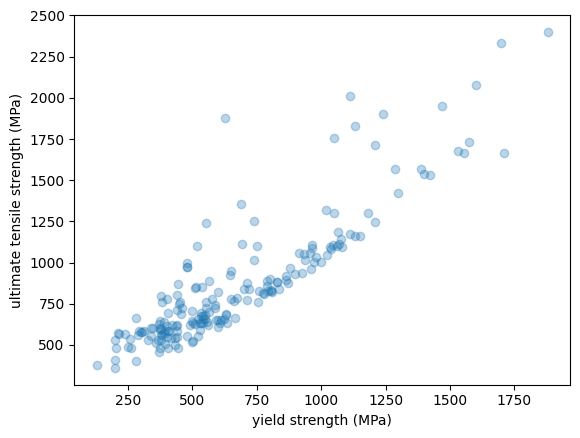

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.3)  # alpha makes the overlapping points readable
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')

The cloud rises to the right, so alloys with a high yield strength tend to have a high tensile strength.
The points sit in a band rather than on a line, which is what we would expect from a hundred different studies.

"Rises to the right" is a description, not a measurement.
The **Pearson correlation coefficient**, written `r`, puts one number on how close a cloud of points comes to a straight line.

In [6]:
correlation = stats.pearsonr(x, y)
print(f'r = {correlation.statistic:.3f}')

r = 0.882


`r` runs from -1 to +1.

Its sign gives the direction, while its distance from zero measures the strength of the linear relationship.
A value of 1 or -1 puts every point on a line; a value near 0 means there is little linear pattern, although a curved relationship could still be present.

0.882 is a strong positive relationship, and the width of the band is why it is not closer to 1.

## What `r` does not say

A large `r` says the two columns move together, not that one causes the other.

Chemistry, processing and microstructure can affect both properties, so a third factor can move them together.

An `r` this size is a reason to go looking for a mechanism rather than a substitute for finding one.

### [Check your understanding]

`DAR_pct` is the deformation at rupture, how far a specimen stretched before it broke, as a percentage.

1. Build a table called `ductile` holding the rows where `YS_MPa` and `DAR_pct` are both reported, using `.dropna` with those two column names.
2. Print how many alloys that leaves.
3. Make a `fig, ax` scatter of `DAR_pct` against `YS_MPa`.
4. Label both axes.
5. Compute the Pearson `r` with `stats.pearsonr`, then print the result's `.statistic` field.
6. In a comment, give the sign and the size of that `r`, and what the sign means for someone choosing an alloy.

*That number supports no claim about which way any causation runs, or whether there is any.*

# What a model is

Everything after this point produces a **model**, so it is worth saying what one is before we build it.

A model is a simplified representation of something, kept because we can use it to answer a practical question.
It is not a claim to be an exact description: the test of a model is whether it is useful, not whether it is right about every case.

A line through these 190 alloys is a model of the average relationship between the two strengths.
Individual alloys are not required to sit on it.

A straight line is a common first model because two numbers, a slope and an intercept, describe the whole thing, and both can be read in the units of the data.

# Fitting a line: `stats.linregress`

`r` describes how closely the points follow a line, but not the line's slope or intercept.
`stats.linregress` fits `y = m*x + b` by least squares and returns an object with named fields.
Least squares returns the line with the smallest total squared vertical gaps from the data.

In [7]:
fit = stats.linregress(x, y)

print(f'slope     = {fit.slope:.3f}')
print(f'intercept = {fit.intercept:.1f} MPa')
print(f'r         = {fit.rvalue:.3f}')

slope     = 0.985
intercept = 204.3 MPa
r         = 0.882


`fit.rvalue` is the same 0.882 stored in `correlation.statistic`.
The fit contains it because the correlation and the line are two answers to one question about these columns.

## Drawing the fitted line

The equation gives a predicted tensile strength for every measured yield strength.
So the obvious thing to try is to run the whole yield strength column through it and plot what comes out.

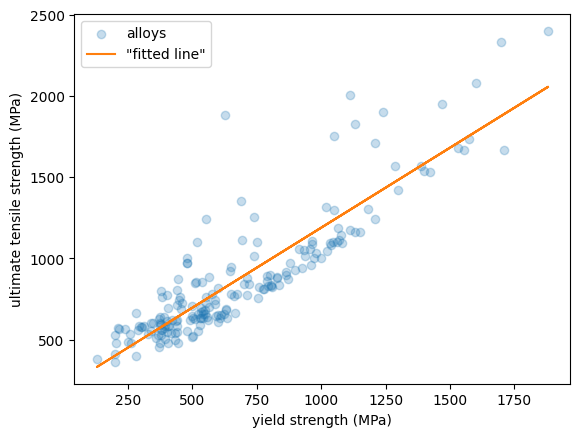

In [8]:
y_line = fit.slope * x + fit.intercept  # a predicted UTS for every alloy

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.25, label='alloys')
ax.plot(x, y_line, color='tab:orange', label='"fitted line"')
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')
ax.legend()

Every one of those predicted points sits on the straight line, and the picture is a scribble.

`ax.plot` draws a segment from each point to the next one in the order they are stored, and `x` is in whatever order the compilation happened to list the alloys.
So the line is drawn to a high yield strength, back to a low one, forward again: across its 189 segments the direction reverses 80 times, retracing the same fitted line.

## Two x values instead of the whole column

A straight line needs exactly two points, so take the smallest and largest yield strength and put those through the equation.
The smallest and largest are guaranteed to be in order, which is the whole of the problem above.

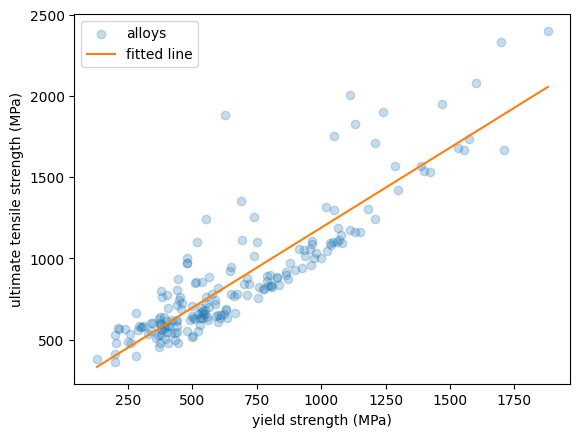

In [9]:
import numpy as np

xx = np.array([np.min(x), np.max(x)])
yy = fit.slope * xx + fit.intercept

fig, ax = plt.subplots()
ax.scatter(x, y, alpha=0.25, label='alloys')
ax.plot(xx, yy, color='tab:orange', label='fitted line')
ax.set_xlabel('yield strength (MPa)')
ax.set_ylabel('ultimate tensile strength (MPa)')
ax.legend()

## Reading the fitted equation

The fitted line is `UTS = 0.985 * YS + 204`.
Because both axes use MPa, the slope means 0.985 MPa of predicted tensile strength per 1 MPa of yield strength.

The intercept is the model's predicted tensile strength at zero yield strength, which lies outside the measured range and has no direct implant interpretation.

Since the slope is close to 1, the predicted gap between tensile and yield strength changes only slowly across the data.

## What the slope does not show

One number for the whole compilation does not describe how much the alloys differ.

In [10]:
margin = y - x

print(f'smallest margin: {np.min(margin):.0f} MPa')
print(f'mean margin:     {np.mean(margin):.0f} MPa')
print(f'median margin:   {np.median(margin):.0f} MPa')
print(f'largest margin:  {np.max(margin):.0f} MPa')

smallest margin: -45 MPa
mean margin:     194 MPa
median margin:   143 MPa
largest margin:  1254 MPa


The measured margins average 194 MPa, but they range from below zero to more than 1200 MPa.
A designer choosing one alloy for one implant needs that alloy's own two measurements, not the average relationship.

# Prediction, inside and outside the data

Substituting a yield strength into the fitted equation gives a predicted tensile strength.

In [11]:
pred_800 = fit.slope * 800 + fit.intercept
print(f'800 MPa yield strength predicts {pred_800:.0f} MPa tensile strength')
print(f'predicted margin: {pred_800 - 800:.0f} MPa')

800 MPa yield strength predicts 992 MPa tensile strength
predicted margin: 192 MPa


The alloys this line was fit on run from 130 to 1880 MPa of yield strength, so 800 sits well inside them.
A prediction inside the fitted range is **interpolation**, and the surrounding data is what supports it.

In [12]:
print(f'{np.min(x):.0f} to {np.max(x):.0f} MPa of yield strength in the fitted alloys')

pred_2500 = fit.slope * 2500 + fit.intercept
print(f'2500 MPa yield strength predicts {pred_2500:.0f} MPa tensile strength')

130 to 1880 MPa of yield strength in the fitted alloys
2500 MPa yield strength predicts 2666 MPa tensile strength


2500 MPa is beyond every alloy in the table, which makes that second number **extrapolation**.

Python returned a value because the calculation applies the equation without checking the fitted range.
This compilation does not support extending the same slope that far.

# Summary

* The Pearson `r` measures how close two columns come to a straight line, from -1 to +1.
* The sign of `r` is the direction and its size is the strength.
* A large `r` does not establish that one property causes the other.
* `stats.linregress` returns the fitted line as `slope`, `intercept` and `rvalue`.
* A slope has units of y per x; an intercept has the units of y and describes the model at x equal to zero.
* Interpolation predicts inside the fitted range, and extrapolation runs the same arithmetic where no data supports it.

Across 190 titanium-alloy records, tensile strength rises about 0.985 MPa for each additional MPa of yield strength.
At 800 MPa yield strength, the line predicts a margin near 192 MPa; the measured margins vary widely from alloy to alloy.

# Before Quiz 4

Quiz 4 covers Lectures 9, 10 and 11, not today's regression.

It uses three of the question formats Midterm 1 will use.

In the first question you read printed output, say what each number means, and caption one of them by naming the population it describes.
In the second you read a marked line of code and write one sentence on what that line does and why it is there for this data, the way the inline comments in these notebooks do.

Then you judge a plotting choice and say why it is the wrong one.

You do not need to write code from scratch, on the quiz or on the exam.

## Further reading

- Salvador, C. A. F. et al. "A compilation of experimental data on the mechanical properties and microstructural features of Ti-alloys." *Scientific Data* 9, 188 (2022). https://doi.org/10.1038/s41597-022-01283-9
- [SciPy documentation: `scipy.stats.pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html)
- [SciPy documentation: `scipy.stats.linregress`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html)

# Appendix A: what other values of `r` look like

The only correlation we measured today was 0.882, which is a strong one.
Here are four more pairs from the same compilation for comparison.

`HV` is the Vickers hardness, measured by pressing a diamond into the surface and measuring the dent.
`YM_GPa` is Young's modulus, the stiffness of the alloy in the elastic region before it yields.
`DAR_pct` is the deformation at rupture, how far a specimen stretched before it broke.

In [13]:
hardness = data.dropna(subset=['YS_MPa', 'HV'])
stiffness = data.dropna(subset=['YM_GPa', 'YS_MPa'])
ductility = data.dropna(subset=['Ti_frac', 'DAR_pct'])
composition = data.dropna(subset=['Al_frac', 'Ti_frac'])

print(f"YS and HV:        r = {stats.pearsonr(hardness['YS_MPa'], hardness['HV']).statistic:.3f}")
print(f"YM and YS:        r = {stats.pearsonr(stiffness['YM_GPa'], stiffness['YS_MPa']).statistic:.3f}")
print(f"Ti and DAR:       r = {stats.pearsonr(ductility['Ti_frac'], ductility['DAR_pct']).statistic:.3f}")
print(f"Al and Ti:        r = {stats.pearsonr(composition['Al_frac'], composition['Ti_frac']).statistic:.3f}")

YS and HV:        r = 0.875
YM and YS:        r = 0.511
Ti and DAR:       r = -0.014
Al and Ti:        r = -0.300


`ax.set_title` puts a title on one panel, one call per subplot.

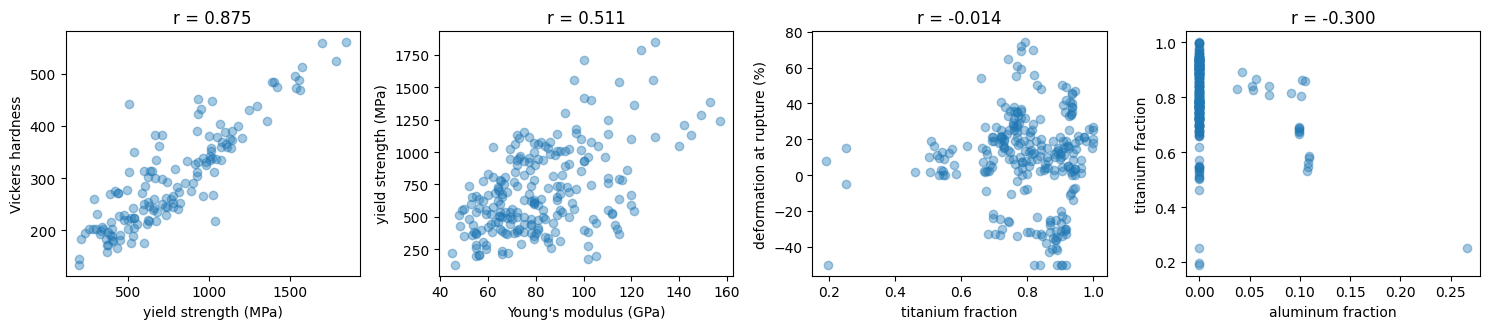

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))

axes[0].scatter(hardness['YS_MPa'], hardness['HV'], alpha=0.4)
axes[0].set_title('r = 0.875')
axes[0].set_xlabel('yield strength (MPa)')
axes[0].set_ylabel('Vickers hardness')

axes[1].scatter(stiffness['YM_GPa'], stiffness['YS_MPa'], alpha=0.4)
axes[1].set_title('r = 0.511')
axes[1].set_xlabel("Young's modulus (GPa)")
axes[1].set_ylabel('yield strength (MPa)')

axes[2].scatter(ductility['Ti_frac'], ductility['DAR_pct'], alpha=0.4)
axes[2].set_title('r = -0.014')
axes[2].set_xlabel('titanium fraction')
axes[2].set_ylabel('deformation at rupture (%)')

axes[3].scatter(composition['Al_frac'], composition['Ti_frac'], alpha=0.4)
axes[3].set_title('r = -0.300')
axes[3].set_xlabel('aluminum fraction')
axes[3].set_ylabel('titanium fraction')

fig.tight_layout()

The first panel is nearly as tight as today's fit, and hardness is measured by resisting a small permanent dent, much as yield strength is the stress that causes a permanent bend.

The second is the same sign and half the size, and the band is visibly wider.
Stiffness comes mostly from the bonding, while yield strength depends on the microstructure, so the two are related without being tied together.

The third panel shows what an `r` near zero looks like: a cloud with no tilt to it.
There is no linear trend in those points to measure.

The fourth is negative, and the cloud falls to the right.
Because elemental fractions sum to one, increasing the aluminum fraction can reduce the titanium fraction even without a broader metallurgical relationship.

A negative `r` on a composition pair like that one is a constraint of how the alloy was mixed, not a discovery about how metals behave.

# Appendix B: the rest of the `linregress` result

`fit` contains more than the three fields we read today.

In [15]:
print(fit)

LinregressResult(slope=np.float64(0.9845743208599055), intercept=np.float64(204.2655718818903), rvalue=np.float64(0.8821839049417173), pvalue=np.float64(2.1357158193744694e-63), stderr=np.float64(0.03833043868335523), intercept_stderr=np.float64(29.035579557337773))


Today we used `fit.slope`, `fit.intercept`, and `fit.rvalue`.
The remaining fields belong to statistics we have not covered, and we will leave them alone until we have.

Reading a field by name is what makes that possible: `fit.slope` selects which number we retrieve, so we can leave the fields we have not met unused.